# 模块六 · 监督学习核心算法

## 6.4 集成学习（Ensemble Learning）

**课时安排：约3课时**

> "三个臭皮匠，顶个诸葛亮"

集成学习的核心思想是将多个"弱学习器"组合成一个"强学习器"，通过**群体智慧**提升模型性能。这是机器学习竞赛中最常使用的技术之一。

---

### 本节目录

1. 集成学习核心思想
2. Bagging 方法（Bootstrap Aggregating）
3. 随机森林原理
4. Boosting 方法（AdaBoost 原理）
5. 梯度提升（Gradient Boosting）与 XGBoost 概述
6. 🧪 随机森林与 AdaBoost 实战
7. 💡 练习题

---

## 1. 集成学习核心思想

### 基本原理

集成学习通过构建**多个基学习器（base learners）** 并将它们组合，来获得比任何单个学习器更好的泛化性能。

### 类比理解

| 场景 | 单个模型 | 集成模型 |
|------|----------|----------|
| 考试 | 一个学生答题 | 全班投票选最佳答案 |
| 医疗诊断 | 一个医生诊断 | 多专家会诊 |
| 预测比赛 | 单人预测 | 多人平均预测 |

### 集成学习为什么有效？

假设有 $T$ 个独立基学习器，每个准确率为 $p$，则集成模型（多数投票）的准确率为：

$$P_{\text{ensemble}} = \sum_{k=\lceil T/2 \rceil}^{T} \binom{T}{k} p^k (1-p)^{T-k}$$

**数值例子**：当 $p = 0.6$（仅略好于随机）：
- $T=3$：$P_{\text{ensemble}} \approx 0.648$
- $T=11$：$P_{\text{ensemble}} \approx 0.753$
- $T=101$：$P_{\text{ensemble}} \approx 0.958$

> 💡 即使每个弱学习器只比随机猜测好一点点，足够多的弱学习器组合后也可以达到很高的准确率！

### 集成学习的两大流派

| 流派 | 策略 | 代表算法 | 基学习器关系 |
|------|------|----------|-------------|
| **Bagging** | 并行构建，降低方差 | 随机森林 | 独立、并行 |
| **Boosting** | 串行构建，降低偏差 | AdaBoost, XGBoost | 依赖、串行 |

---

## 2. Bagging 方法（Bootstrap Aggregating）

### 核心思想

Bagging 由 Leo Breiman 于1996年提出：

1. **Bootstrap 采样**：从训练集中**有放回**地随机抽取 $m$ 个样本，生成 $T$ 个不同的训练子集
2. **独立训练**：在每个子集上独立训练一个基学习器
3. **聚合（Aggregating）**：
   - 分类：**多数投票**
   - 回归：**平均**

```
训练集 D (m 个样本)
  ├── Bootstrap 采样 → D₁ → 训练 → 模型 h₁
  ├── Bootstrap 采样 → D₂ → 训练 → 模型 h₂
  ├── Bootstrap 采样 → D₃ → 训练 → 模型 h₃
  ├── ...
  └── Bootstrap 采样 → D_T → 训练 → 模型 h_T

预测: H(x) = 多数投票 {h₁(x), h₂(x), ..., h_T(x)}
```

### Bootstrap 采样的性质

- 每个子集包含约 **63.2%** 的原始样本（唯一样本比例 $= 1 - (1-1/m)^m \to 1 - e^{-1} \approx 0.632$）
- 约 **36.8%** 的样本不被选中（称为 **OOB 样本**）
- OOB 样本可用于**无验证集的误差估计**！

### Bagging 的数学解释

对于回归问题，Bagging 预测：

$$H(\mathbf{x}) = \frac{1}{T}\sum_{t=1}^{T} h_t(\mathbf{x})$$

**方差分析**：如果各基学习器有方差 $\sigma^2$ 且两两相关系数为 $\rho$：

$$\text{Var}(H) = \rho \sigma^2 + \frac{1-\rho}{T} \sigma^2$$

- 当 $\rho = 0$（完全不相关）：$\text{Var}(H) = \sigma^2 / T$，方差降低 $T$ 倍！
- 当 $\rho = 1$（完全相同）：$\text{Var}(H) = \sigma^2$，无改善
- **Bagging 通过引入多样性（降低 $\rho$）来减小方差**

---

## 3. 随机森林原理（Random Forest）

### 核心思想

随机森林是 Bagging 的**特化版本**，以**决策树**为基学习器，并额外引入了**随机特征选择**来进一步增强多样性。

### 相比 Bagging 的改进

在训练每棵决策树时，不仅仅是 Bootstrap 采样数据，还在每个节点分裂时：

- 从所有 $n$ 个特征中**随机选择 $k$ 个特征**作为候选
- 仅在这 $k$ 个候选特征中选择最优分裂

通常 $k = \lfloor \sqrt{n} \rfloor$（分类）或 $k = \lfloor n/3 \rfloor$（回归）。

### 随机森林的构建过程

```
for t = 1 to T:
    1. 从 D 中 Bootstrap 采样得到 D_t
    2. 在 D_t 上训练决策树：
       - 每个节点：随机选 k 个特征
       - 从 k 个特征中选最优分裂
       - 不剪枝（让树充分生长）
    3. 得到决策树 h_t

预测: H(x) = 多数投票 {h₁(x), ..., h_T(x)}
```

### OOB 误差（Out-of-Bag Error）

每棵树约使用 63.2% 的训练数据，剩余 36.8% 的 OOB 数据可用于评估：

1. 对每个样本 $x^{(i)}$，找到所有**未使用**该样本的树
2. 用这些树对 $x^{(i)}$ 进行预测（多数投票）
3. OOB 误差 = 被错误分类的 OOB 样本比例

$$\text{OOB Error} = \frac{1}{m} \sum_{i=1}^{m} \mathbb{I}\left( \hat{y}^{(i)}_{\text{OOB}} \neq y^{(i)} \right)$$

> OOB 误差相当于**免费的交叉验证**，无需单独划分验证集。

### 随机森林的优势

| 优势 | 说明 |
|------|------|
| **高准确率** | 集成+随机性，泛化能力强 |
| **抗过拟合** | 多树投票平滑了单树的过拟合 |
| **特征重要性** | 可评估各特征的重要程度 |
| **并行化** | 各树独立训练，适合并行计算 |
| **鲁棒性** | 对噪声和缺失值不敏感 |

---

## 4. Boosting 方法（AdaBoost 原理）

### Boosting vs Bagging

| 对比 | Bagging | Boosting |
|------|---------|----------|
| **训练方式** | 并行、独立 | 串行、依赖 |
| **样本权重** | 均等 | 动态调整 |
| **关注重点** | 降低方差 | 降低偏差 |
| **过拟合风险** | 较低 | 较高（需调参） |

### AdaBoost（Adaptive Boosting）原理

AdaBoost 由 Freund 和 Schapire 于1997年提出，核心思想：

> 每一轮训练一个弱学习器，**被前一轮错误分类的样本在下一轮获得更大权重**。

### AdaBoost 算法流程

**输入**：训练集 $\{(x^{(i)}, y^{(i)})\}_{i=1}^{m}$，$y^{(i)} \in \{-1, +1\}$，迭代轮数 $T$

**初始化**：$w_1^{(i)} = \frac{1}{m}$

**For $t = 1, 2, \dots, T$:**

1. **使用权重 $w_t$ 训练弱学习器 $h_t$**
2. **计算加权错误率**：
   $$\epsilon_t = \sum_{i: h_t(x^{(i)}) \neq y^{(i)}} w_t^{(i)}$$
3. **计算学习器权重**：
   $$\alpha_t = \frac{1}{2} \ln \left( \frac{1 - \epsilon_t}{\epsilon_t} \right)$$
   - 错误率越低 → $\alpha_t$ 越大 → 该学习器投票权重越大
4. **更新样本权重**：
   $$w_{t+1}^{(i)} = \frac{w_t^{(i)} \cdot \exp(-\alpha_t \cdot y^{(i)} \cdot h_t(x^{(i)}))}{Z_t}$$
   - 分类正确的样本权重降低
   - 分类错误的样本权重增大
   - $Z_t$ 是归一化因子

**最终预测**：
$$H(x) = \text{sign}\left( \sum_{t=1}^{T} \alpha_t \cdot h_t(x) \right)$$

### AdaBoost 直观理解

```
第1轮: 训练 h₁ → 错误率 0.30 → α₁ = 0.85
  ├── 正确分类的样本：权重降低 ↓
  └── 错误分类的样本：权重增大 ↑（下一轮重点关注）

第2轮: 训练 h₂（关注之前错分的样本） → 错误率 0.25 → α₂ = 1.10
  ├── 正确分类的样本：权重降低 ↓
  └── 错误分类的样本：权重增大 ↑

第3轮: 训练 h₃ → 错误率 0.20 → α₃ = 1.39

...

最终: H(x) = sign(α₁h₁(x) + α₂h₂(x) + α₃h₃(x) + ...)
```

> 每一轮新学习器都专注于前一轮表现不好的"困难样本"，逐步提升整体性能。

---

## 5. 梯度提升（Gradient Boosting）与 XGBoost 概述

### 梯度提升框架

梯度提升是 Boosting 的推广框架（Friedman, 2001）：

核心思想：**每一轮新学习器拟合的是损失函数关于当前模型的负梯度（即残差的近似）**。

$$F_t(\mathbf{x}) = F_{t-1}(\mathbf{x}) + h_t(\mathbf{x})$$

其中 $h_t$ 通过拟合**伪残差**来训练：

$$r_i^{(t)} = -\left[ \frac{\partial L(y_i, F(x_i))}{\partial F(x_i)} \right]_{F=F_{t-1}}$$

### 梯度提升 vs AdaBoost

| 对比 | AdaBoost | Gradient Boosting |
|------|----------|-------------------|
| **基学习器** | 任意弱学习器 | 通常是回归树 |
| **优化方式** | 指数损失 | 任意可导损失函数 |
| **权重更新** | 样本权重 | 函数空间的梯度下降 |
| **灵活性** | 较低 | 高（可自定义损失） |

### XGBoost 概述

**XGBoost（eXtreme Gradient Boosting）** 由陈天奇于2016年提出，是梯度提升的高效实现，是数据竞赛中的"利器"。

#### 关键改进

1. **正则化**：目标函数中加入正则项防止过拟合
   $$\text{Obj} = \sum_{i=1}^{m} L(y_i, \hat{y}_i) + \sum_{t=1}^{T} \Omega(h_t)$$
   其中 $\Omega(h) = \gamma T + \frac{1}{2}\lambda \|w\|^2$

2. **二阶泰勒展开**：利用二阶导数加速收敛
   $$\text{Obj}^{(t)} \approx \sum_{i=1}^{m} \left[ g_i f_t(x_i) + \frac{1}{2} h_i f_t^2(x_i) \right] + \Omega(f_t)$$
   其中 $g_i = \partial_{\hat{y}^{(t-1)}} L, h_i = \partial^2_{\hat{y}^{(t-1)}} L$

3. **列采样**：类似随机森林的随机特征选择

4. **缺失值处理**：自动学习缺失值的分裂方向

5. **并行化**：特征级别的并行计算

### 常用参数速查

| 参数 | 含义 | 建议值 |
|------|------|--------|
| `n_estimators` | 树的数量 | 100-1000 |
| `max_depth` | 树的最大深度 | 3-10 |
| `learning_rate` | 学习率（收缩系数） | 0.01-0.3 |
| `subsample` | 行采样比例 | 0.6-1.0 |
| `colsample_bytree` | 列采样比例 | 0.6-1.0 |
| `reg_alpha` (L1) | L1 正则化 | 0-10 |
| `reg_lambda` (L2) | L2 正则化 | 0-10 |
| `gamma` | 最小损失减小 | 0-5 |

> ⚠️ **经验法则**：降低 `learning_rate` 时应增大 `n_estimators`。

### 集成学习算法家族

```
集成学习
├── Bagging
│   ├── Bagging (通用框架)
│   └── 随机森林 (Random Forest) ★★★
│
├── Boosting
│   ├── AdaBoost ★★
│   ├── Gradient Boosting (GBDT) ★★
│   ├── XGBoost ★★★★★
│   ├── LightGBM ★★★★★
│   └── CatBoost ★★★★
│
└── Stacking (堆叠)
    └── 将不同基学习器的输出作为新特征
```

---

## 6. 🧪 随机森林与 AdaBoost 实战

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['font.sans-serif'] = ['SimHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

# ========================
# 生成数据集
# ========================
np.random.seed(42)
X, y = make_classification(
    n_samples=1000, n_features=2, n_redundant=0,
    n_informative=2, n_clusters_per_class=2,
    class_sep=1.5, random_state=42
)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

print(f"数据集: 训练集 {X_train.shape[0]}, 测试集 {X_test.shape[0]}, 特征 {X.shape[1]}")

数据集: 训练集 700, 测试集 300, 特征 2


In [2]:
# ========================
# 导入模型
# ========================
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier, 
    AdaBoostClassifier,
    GradientBoostingClassifier,
    BaggingClassifier
)

# ========================
# 单棵决策树作为基线
# ========================
dt = DecisionTreeClassifier(max_depth=None, random_state=42)
dt.fit(X_train_s, y_train)
dt_acc = accuracy_score(y_test, dt.predict(X_test_s))
print(f"单棵决策树准确率: {dt_acc:.4f}")

# ========================
# 随机森林
# ========================
rf = RandomForestClassifier(n_estimators=100, max_depth=None, random_state=42, oob_score=True)
rf.fit(X_train_s, y_train)
rf_acc = accuracy_score(y_test, rf.predict(X_test_s))
rf_oob = rf.oob_score_
print(f"\n随机森林准确率:  {rf_acc:.4f}")
print(f"随机森林OOB误差:  1-{rf_oob:.4f} = {1-rf_oob:.4f}")

# ========================
# AdaBoost
# ========================
ada = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(max_depth=3),
    n_estimators=100, learning_rate=0.5, random_state=42
)
ada.fit(X_train_s, y_train)
ada_acc = accuracy_score(y_test, ada.predict(X_test_s))
print(f"\nAdaBoost准确率:   {ada_acc:.4f}")

# ========================
# Gradient Boosting
# ========================
gb = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42)
gb.fit(X_train_s, y_train)
gb_acc = accuracy_score(y_test, gb.predict(X_test_s))
print(f"Gradient Boosting: {gb_acc:.4f}")

# ========================
# Bagging (决策树基学习器)
# ========================
bag = BaggingClassifier(
    estimator=DecisionTreeClassifier(),
    n_estimators=100, random_state=42, oob_score=True
)
bag.fit(X_train_s, y_train)
bag_acc = accuracy_score(y_test, bag.predict(X_test_s))
bag_oob = bag.oob_score_
print(f"\nBagging准确率:    {bag_acc:.4f}")
print(f"Bagging OOB误差:   1-{bag_oob:.4f} = {1-bag_oob:.4f}")

单棵决策树准确率: 0.9533

随机森林准确率:  0.9667
随机森林OOB误差:  1-0.9629 = 0.0371

AdaBoost准确率:   0.9567
Gradient Boosting: 0.9600

Bagging准确率:    0.9667
Bagging OOB误差:   1-0.9657 = 0.0343


In [3]:
# ========================
# 性能对比汇总
# ========================
results_all = {
    '单棵决策树': dt_acc,
    'Bagging': bag_acc,
    '随机森林': rf_acc,
    'AdaBoost': ada_acc,
    'Gradient Boosting': gb_acc,
}

print("=" * 45)
print(f"{'算法':<22} {'测试准确率':>12}")
print("=" * 45)
for name, acc in results_all.items():
    marker = " ← 单模型基线" if name == "单棵决策树" else ""
    print(f"{name:<22} {acc:>12.4f}{marker}")
print("=" * 45)
print("\n✅ 所有集成方法都优于单棵决策树！")

算法                            测试准确率
单棵决策树                        0.9533 ← 单模型基线
Bagging                      0.9667
随机森林                         0.9667
AdaBoost                     0.9567
Gradient Boosting            0.9600

✅ 所有集成方法都优于单棵决策树！


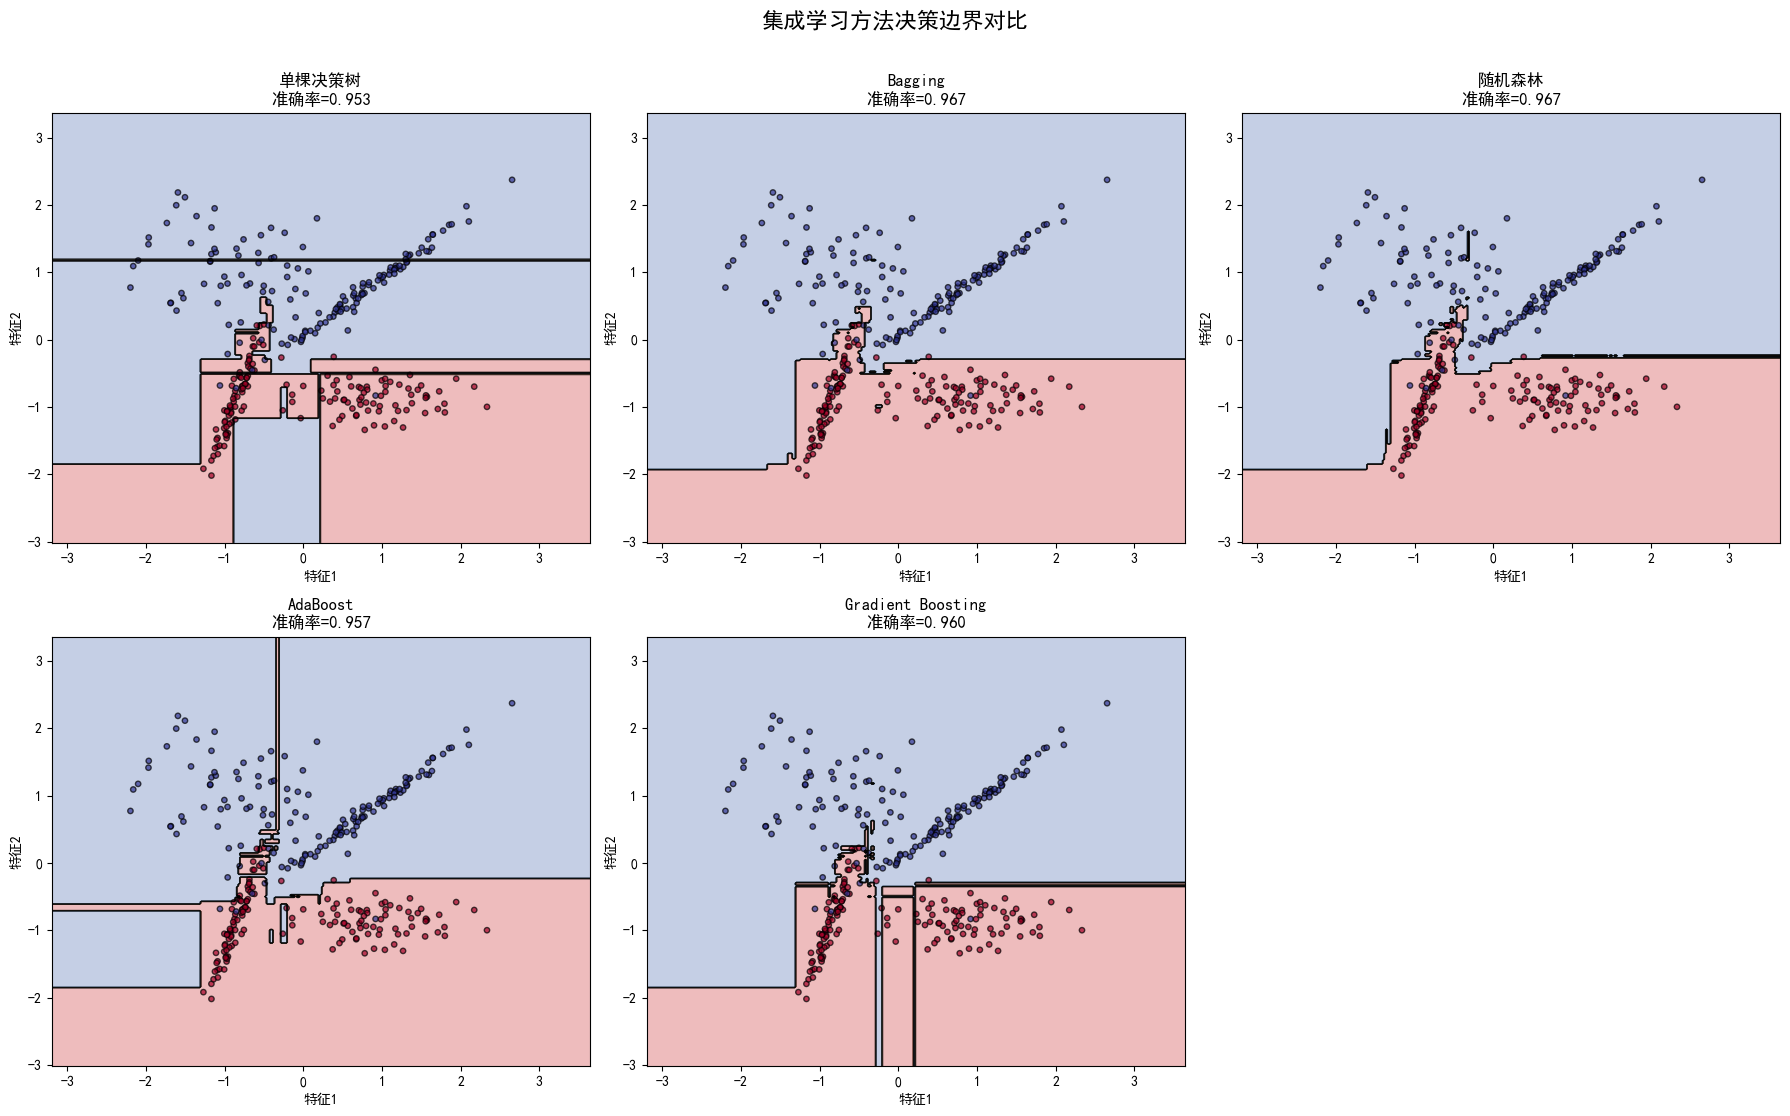

In [4]:
# ========================
# 可视化1: 决策边界对比
# ========================
models_vis = {
    '单棵决策树': dt,
    'Bagging': bag,
    '随机森林': rf,
    'AdaBoost': ada,
    'Gradient Boosting': gb,
}

fig, axes = plt.subplots(2, 3, figsize=(18, 11))
axes = axes.flatten()

for idx, (name, model) in enumerate(models_vis.items()):
    ax = axes[idx]
    h = 0.02
    x_min, x_max = X_test_s[:, 0].min() - 1, X_test_s[:, 0].max() + 1
    y_min, y_max = X_test_s[:, 1].min() - 1, X_test_s[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    
    ax.contourf(xx, yy, Z, alpha=0.3, cmap=plt.cm.RdYlBu)
    ax.contour(xx, yy, Z, colors='k', linewidths=0.3)
    ax.scatter(X_test_s[:, 0], X_test_s[:, 1], c=y_test, cmap=plt.cm.RdYlBu,
               edgecolors='k', s=15, alpha=0.7)
    ax.set_title(f'{name}\n准确率={results_all[name]:.3f}', fontsize=12)
    ax.set_xlabel('特征1'); ax.set_ylabel('特征2')

# 隐藏多余的子图
axes[-1].set_visible(False)

plt.suptitle('集成学习方法决策边界对比', fontsize=16, y=1.01)
plt.tight_layout()
plt.show()

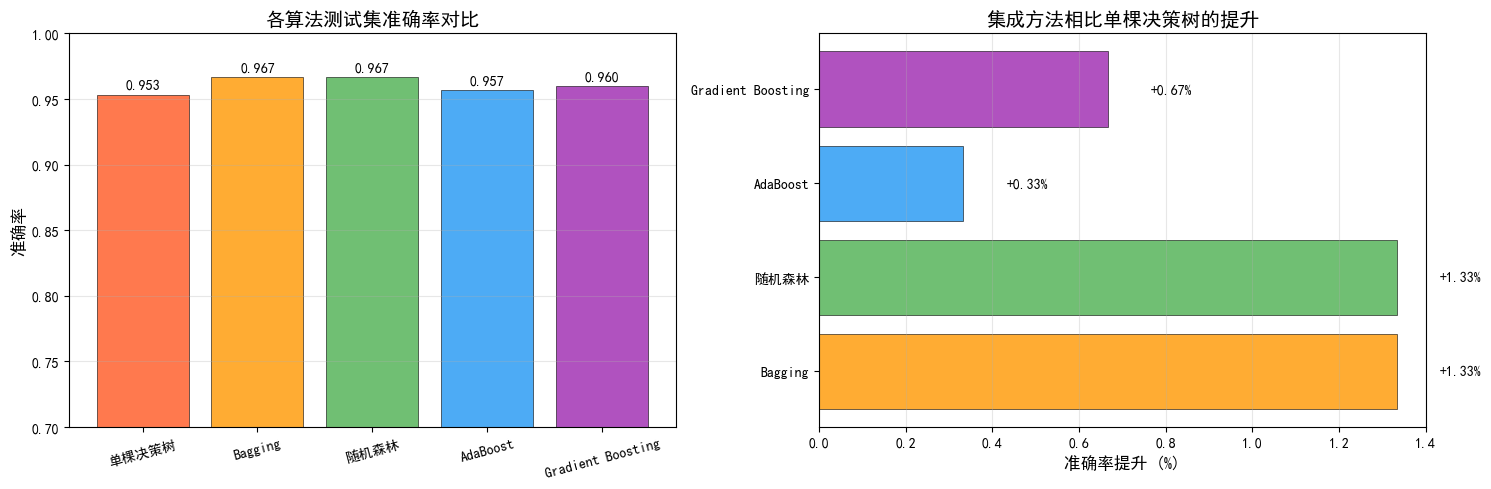

In [5]:
# ========================
# 可视化2: 准确率对比柱状图 + 集成效果提升
# ========================
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

names = list(results_all.keys())
accs = list(results_all.values())
colors = ['#FF5722', '#FF9800', '#4CAF50', '#2196F3', '#9C27B0']

# 准确率柱状图
ax1 = axes[0]
bars = ax1.bar(names, accs, color=colors, alpha=0.8, edgecolor='black', linewidth=0.5)
ax1.set_ylim(0.7, 1.0)
ax1.set_ylabel('准确率', fontsize=12)
ax1.set_title('各算法测试集准确率对比', fontsize=14)
ax1.grid(axis='y', alpha=0.3)
ax1.tick_params(axis='x', rotation=15)
for bar, acc in zip(bars, accs):
    ax1.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.003,
             f'{acc:.3f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

# 集成 vs 单模型的提升
ax2 = axes[1]
improvements = {}
for name in names:
    if name != "单棵决策树":
        improvements[name] = (results_all[name] - results_all["单棵决策树"]) * 100

ax2.barh(list(improvements.keys()), list(improvements.values()), 
         color=colors[1:], alpha=0.8, edgecolor='black', linewidth=0.5)
ax2.set_xlabel('准确率提升 (%)', fontsize=12)
ax2.set_title('集成方法相比单棵决策树的提升', fontsize=14)
ax2.grid(axis='x', alpha=0.3)
for i, (name, imp) in enumerate(improvements.items()):
    ax2.text(imp + 0.1, i, f'+{imp:.2f}%', va='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

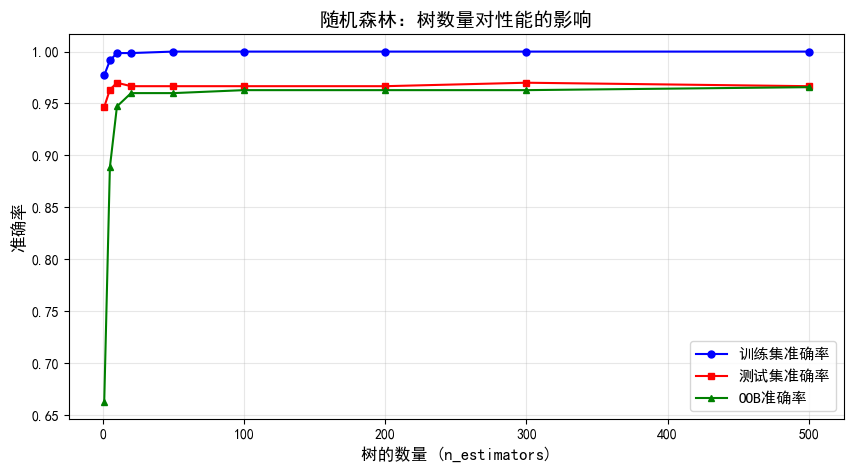

观察：
- 树数量增加 → 测试准确率先快速上升后趋于平稳
- OOB准确率与测试准确率趋势一致，可替代交叉验证
- 训练准确率几乎为1.0（单棵树完全拟合训练数据）


In [6]:
# ========================
# 可视化3: 树数量对随机森林性能的影响
# ========================
n_trees_range = [1, 5, 10, 20, 50, 100, 200, 300, 500]
rf_train_scores = []
rf_test_scores = []
rf_oob_scores = []

for n in n_trees_range:
    rf_temp = RandomForestClassifier(n_estimators=n, random_state=42, oob_score=True)
    rf_temp.fit(X_train_s, y_train)
    rf_train_scores.append(rf_temp.score(X_train_s, y_train))
    rf_test_scores.append(rf_temp.score(X_test_s, y_test))
    rf_oob_scores.append(rf_temp.oob_score_)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(n_trees_range, rf_train_scores, 'b-o', markersize=5, label='训练集准确率', linewidth=1.5)
ax.plot(n_trees_range, rf_test_scores, 'r-s', markersize=5, label='测试集准确率', linewidth=1.5)
ax.plot(n_trees_range, rf_oob_scores, 'g-^', markersize=5, label='OOB准确率', linewidth=1.5)
ax.set_xlabel('树的数量 (n_estimators)', fontsize=12)
ax.set_ylabel('准确率', fontsize=12)
ax.set_title('随机森林：树数量对性能的影响', fontsize=14)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.show()

print("观察：")
print("- 树数量增加 → 测试准确率先快速上升后趋于平稳")
print("- OOB准确率与测试准确率趋势一致，可替代交叉验证")
print("- 训练准确率几乎为1.0（单棵树完全拟合训练数据）")

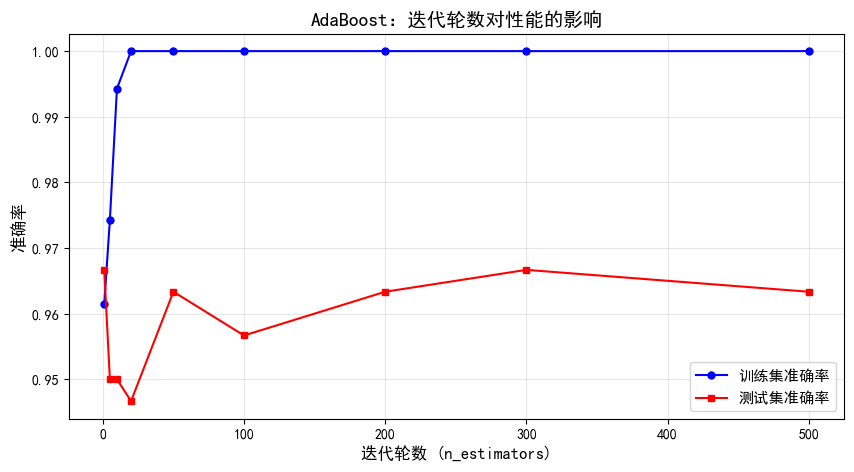

观察：
- 迭代轮数增加 → 准确率先上升后可能下降（过拟合）
- AdaBoost 有过拟合风险，需要通过学习率和轮数控制


In [7]:
# ========================
# 可视化4: AdaBoost 迭代轮数对性能的影响
# ========================
n_rounds = [1, 5, 10, 20, 50, 100, 200, 300, 500]
ada_train_scores = []
ada_test_scores = []
ada_errors = []

for n in n_rounds:
    ada_temp = AdaBoostClassifier(
        estimator=DecisionTreeClassifier(max_depth=3),
        n_estimators=n, learning_rate=0.5, random_state=42
    )
    ada_temp.fit(X_train_s, y_train)
    ada_train_scores.append(ada_temp.score(X_train_s, y_train))
    ada_test_scores.append(ada_temp.score(X_test_s, y_test))
    # 加权错误率
    ada_errors.append(1.0 - ada_temp.score(X_test_s, y_test))

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(n_rounds, ada_train_scores, 'b-o', markersize=5, label='训练集准确率', linewidth=1.5)
ax.plot(n_rounds, ada_test_scores, 'r-s', markersize=5, label='测试集准确率', linewidth=1.5)
ax.set_xlabel('迭代轮数 (n_estimators)', fontsize=12)
ax.set_ylabel('准确率', fontsize=12)
ax.set_title('AdaBoost：迭代轮数对性能的影响', fontsize=14)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.show()

print("观察：")
print("- 迭代轮数增加 → 准确率先上升后可能下降（过拟合）")
print("- AdaBoost 有过拟合风险，需要通过学习率和轮数控制")

Wine数据集 - 随机森林准确率: 1.0000


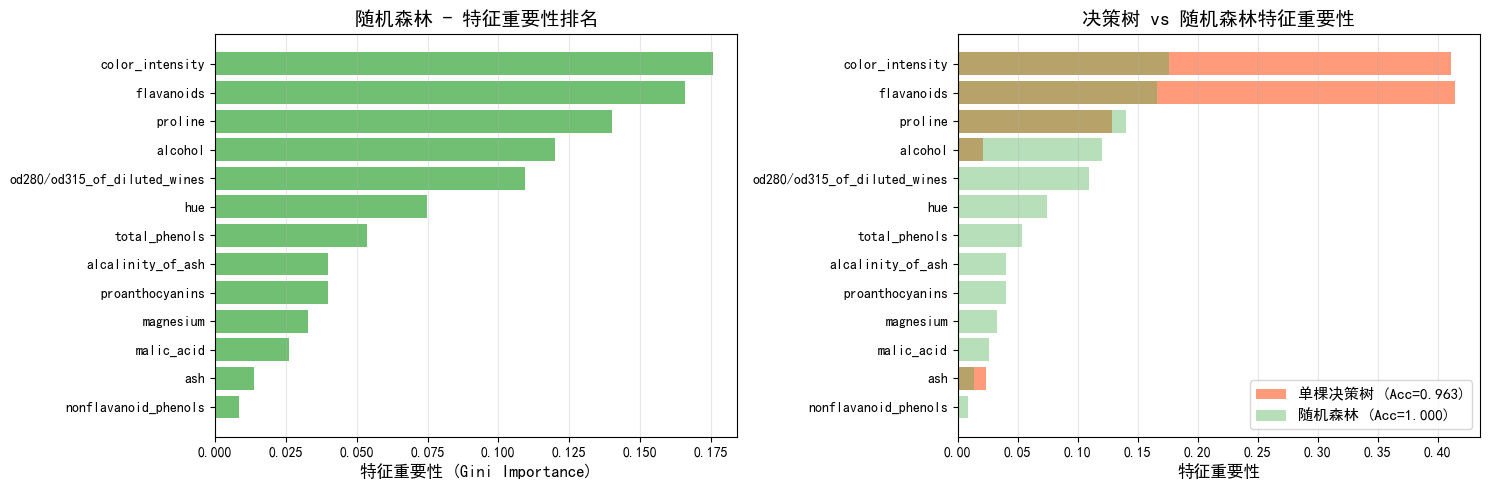

In [8]:
# ========================
# 可视化5: 特征重要性（随机森林）
# ========================
# 使用更高维数据展示特征重要性
from sklearn.datasets import load_wine

wine = load_wine()
X_wine, y_wine = wine.data, wine.target
X_w_train, X_w_test, y_w_train, y_w_test = train_test_split(
    X_wine, y_wine, test_size=0.3, random_state=42
)

rf_wine = RandomForestClassifier(n_estimators=200, random_state=42)
rf_wine.fit(X_w_train, y_w_train)
wine_acc = rf_wine.score(X_w_test, y_w_test)
print(f"Wine数据集 - 随机森林准确率: {wine_acc:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# 特征重要性（基于不纯度减少）
ax1 = axes[0]
importances = rf_wine.feature_importances_
feature_names = wine.feature_names
indices = np.argsort(importances)[::-1]

ax1.barh(range(len(importances)), importances[indices], color='#4CAF50', alpha=0.8)
ax1.set_yticks(range(len(importances)))
ax1.set_yticklabels([feature_names[i] for i in indices], fontsize=10)
ax1.set_xlabel('特征重要性 (Gini Importance)', fontsize=12)
ax1.set_title('随机森林 - 特征重要性排名', fontsize=14)
ax1.grid(axis='x', alpha=0.3)
ax1.invert_yaxis()

# 对比: 单棵决策树 vs 随机森林的特征重要性
ax2 = axes[1]
dt_wine = DecisionTreeClassifier(random_state=42)
dt_wine.fit(X_w_train, y_w_train)
dt_importances = dt_wine.feature_importances_
dt_wine_acc = dt_wine.score(X_w_test, y_w_test)

ax2.barh(range(len(importances)), dt_importances[indices], alpha=0.6, 
         color='#FF5722', label=f'单棵决策树 (Acc={dt_wine_acc:.3f})')
ax2.barh(range(len(importances)), importances[indices], alpha=0.4,
         color='#4CAF50', label=f'随机森林 (Acc={wine_acc:.3f})')
ax2.set_yticks(range(len(importances)))
ax2.set_yticklabels([feature_names[i] for i in indices], fontsize=10)
ax2.set_xlabel('特征重要性', fontsize=12)
ax2.set_title('决策树 vs 随机森林特征重要性', fontsize=14)
ax2.legend(fontsize=11)
ax2.grid(axis='x', alpha=0.3)
ax2.invert_yaxis()

plt.tight_layout()
plt.show()

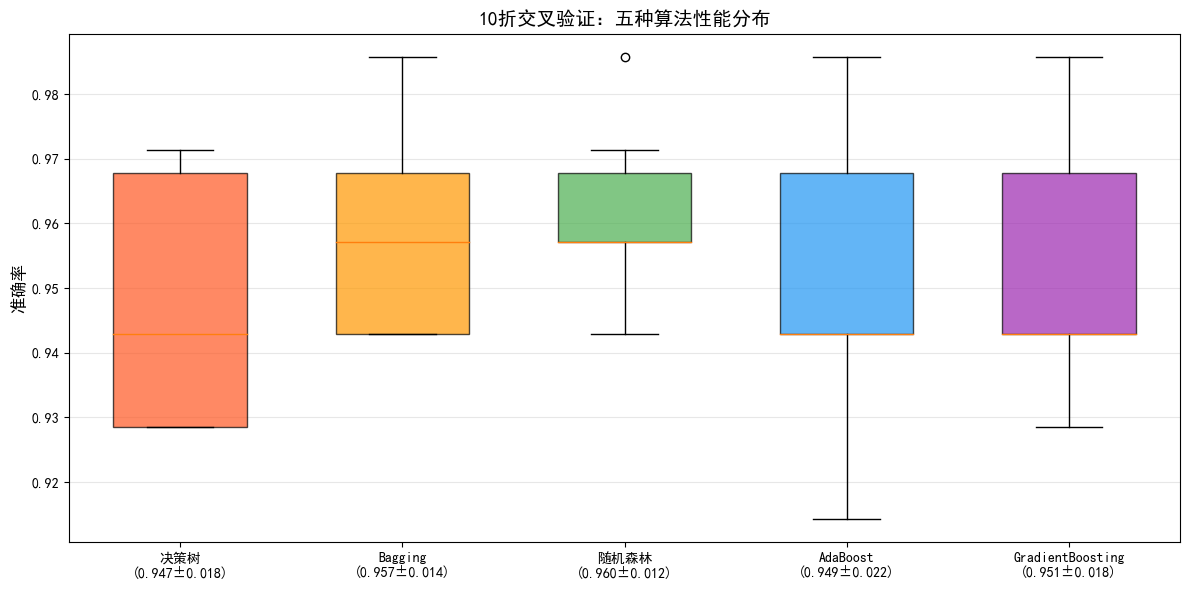


算法                         CV均值        CV标准差
决策树                      0.9471       0.0181
Bagging                  0.9571       0.0143
随机森林                     0.9600       0.0125
AdaBoost                 0.9486       0.0223
GradientBoosting         0.9514       0.0183


In [9]:
# ========================
# 可视化6: 交叉验证全面对比
# ========================
from sklearn.model_selection import StratifiedKFold

models_cv = {
    '决策树': DecisionTreeClassifier(random_state=42),
    'Bagging': BaggingClassifier(n_estimators=100, random_state=42),
    '随机森林': RandomForestClassifier(n_estimators=100, random_state=42),
    'AdaBoost': AdaBoostClassifier(n_estimators=100, random_state=42),
    'GradientBoosting': GradientBoostingClassifier(n_estimators=100, random_state=42),
}

cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

fig, ax = plt.subplots(figsize=(12, 6))
bp_data = []
bp_labels = []
bp_colors = ['#FF5722', '#FF9800', '#4CAF50', '#2196F3', '#9C27B0']

for idx, (name, model) in enumerate(models_cv.items()):
    scores = cross_val_score(model, X_train_s, y_train, cv=cv, scoring='accuracy')
    bp_data.append(scores)
    bp_labels.append(f'{name}\n({scores.mean():.3f}±{scores.std():.3f})')

bp = ax.boxplot(bp_data, labels=bp_labels, patch_artist=True, widths=0.6)
for patch, color in zip(bp['boxes'], bp_colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
ax.set_ylabel('准确率', fontsize=12)
ax.set_title('10折交叉验证：五种算法性能分布', fontsize=14)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print("\n" + "=" * 60)
print(f"{'算法':<20} {'CV均值':>10} {'CV标准差':>12}")
print("=" * 60)
for idx, (name, model) in enumerate(models_cv.items()):
    scores = cross_val_score(model, X_train_s, y_train, cv=cv, scoring='accuracy')
    print(f"{name:<20} {scores.mean():>10.4f} {scores.std():>12.4f}")
print("=" * 60)

=== XGBoost 演示 ===
XGBoost 测试准确率: 0.9700


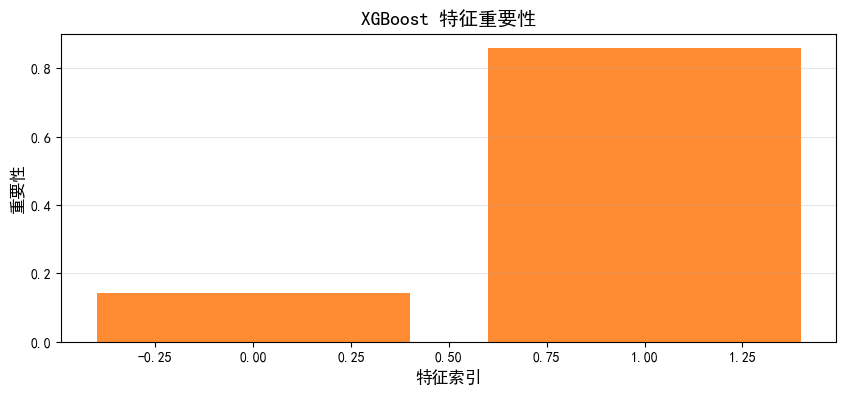


✅ XGBoost 可正常使用！
安装方式: pip install xgboost


In [10]:
# ========================
# （选学）XGBoost 演示
# ========================
try:
    from xgboost import XGBClassifier
    
    xgb = XGBClassifier(
        n_estimators=100, max_depth=3, learning_rate=0.1,
        subsample=0.8, colsample_bytree=0.8, random_state=42,
        use_label_encoder=False, eval_metric='logloss'
    )
    xgb.fit(X_train_s, y_train)
    xgb_acc = accuracy_score(y_test, xgb.predict(X_test_s))
    
    print("=== XGBoost 演示 ===")
    print(f"XGBoost 测试准确率: {xgb_acc:.4f}")
    
    # XGBoost 特征重要性
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.bar(range(len(xgb.feature_importances_)), xgb.feature_importances_, 
           color='#FF6F00', alpha=0.8)
    ax.set_xlabel('特征索引', fontsize=12)
    ax.set_ylabel('重要性', fontsize=12)
    ax.set_title('XGBoost 特征重要性', fontsize=14)
    ax.grid(axis='y', alpha=0.3)
    plt.show()
    
    print("\n✅ XGBoost 可正常使用！")
    print("安装方式: pip install xgboost")
    
except ImportError:
    print("⚠️ XGBoost 未安装，跳过此部分。")
    print("安装方式: pip install xgboost")

---

## 7. 💡 练习题

### 练习1：随机森林超参数调优（基础）

使用 `GridSearchCV` 或 `RandomizedSearchCV` 对随机森林进行超参数调优：
```python
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [3, 5, 10, None],
    'min_samples_split': [2, 5, 10],
}
```
记录最优参数和对应的准确率。

### 练习2：Bagging vs Boosting 对比实验

在 `make_moons(n_samples=1000, noise=0.3)` 数据集上：
1. 分别训练 Bagging 和 AdaBoost（使用不同数量的基学习器）
2. 绘制准确率随基学习器数量变化的曲线
3. 分析两种方法的收敛速度和最终性能

### 练习3：特征重要性分析

使用 `load_breast_cancer` 数据集：
1. 训练随机森林并获取特征重要性
2. 选取 Top-5 和 Top-10 特征分别训练模型
3. 对比使用全部特征 vs 选择特征后的模型性能
4. 分析是否有冗余特征可以剔除

### 练习4：房价预测（回归集成）（选做）

使用 `fetch_california_housing` 数据集：
1. 训练单棵决策树回归 vs 随机森林回归
2. 对比 MSE 和 R²
3. 分析随机森林对异常值的鲁棒性

### 练习5：XGBoost 实战（选做）

安装 XGBoost 后，在 Wine 数据集上：
1. 使用 XGBoost 进行分类
2. 调整 `learning_rate`, `max_depth`, `n_estimators` 等参数
3. 使用早停（early stopping）防止过拟合
4. 与随机森林对比性能

---

> 📌 **本节要点回顾**：
> - 集成学习通过组合多个弱学习器构建强学习器
> - **Bagging**（随机森林）通过并行训练+随机性降低方差，适合减少过拟合
> - **Boosting**（AdaBoost, XGBoost）通过串行训练+关注困难样本降低偏差
> - 随机森林的 OOB 误差提供免费的泛化评估
> - XGBoost 通过正则化、二阶优化等改进，是竞赛中最高效的工具之一
> - **实践中，集成方法通常是首选的基线算法**

---

## 📚 模块六总结

恭喜你完成了模块六"监督学习核心算法"的学习！让我们回顾一下本模块的核心知识：

### 知识体系

```
监督学习核心算法
├── 6.1 线性回归（回归）
│   ├── 假设函数 h(x) = w^T x + b
│   ├── MSE 损失函数
│   ├── 梯度下降 & 正规方程
│   └── 多项式回归
│
├── 6.2 逻辑回归（分类）
│   ├── Sigmoid 函数
│   ├── 交叉熵损失
│   ├── 决策边界
│   └── 多分类扩展
│
├── 6.3 其他经典算法
│   ├── K-NN（懒惰学习）
│   ├── 决策树（信息增益/基尼系数）
│   ├── SVM（最大间隔、核技巧）
│   └── 朴素贝叶斯（条件独立性）
│
└── 6.4 集成学习
    ├── Bagging → 随机森林
    ├── Boosting → AdaBoost
    └── Gradient Boosting → XGBoost
```

### 下一步学习建议

1. **实践**：在 Kaggle 竞赛中使用这些算法（尤其是 XGBoost/随机森林）
2. **深入**：阅读 Scikit-learn 文档，理解每个算法的所有参数
3. **扩展**：了解 LightGBM、CatBoost 等更新的集成方法
4. **理论**：深入阅读《统计学习方法》（李航）和《Hands-On ML》（Aurélien Géron）